# KSB — Pair deltas and gap evolution

Plots gap, velocity delta (Δv), and acceleration delta (Δa) for consecutive input pairs.
Time window: from when the trailing input (follower) enters the buffer until the leading input (leader) trailing edge exits.
The deltas capture relative motion constraints between paired inputs.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from ksb.simulation.ksb_simulation import KSBSimulation
from ksb.simulation.result import SimulationResult
from ksb.planning.solvers.scurve import SCurveSolver

import yaml
from pathlib import Path
with open(Path('..') / 'configs' / 'default.yaml') as f:
    cfg = yaml.safe_load(f)

cfg

{'solver': 'scurve',
 'jmax': 100.0,
 'Vmax': 3.0,
 'Amax': 8.5,
 'L_upstream': 2.0,
 'L_buffer': 2.5,
 'L_registrar': 3.0,
 'L_downstream': 2.0,
 'input_length': 0.32,
 'n_buffer_seg': 4,
 'n_reg_seg': 5,
 'slot_length': 0.6,
 'input_gap_mean': 0.6,
 'input_gap_std': 0.05,
 'arrival_rate_ppm': 120,
 'slot_rate_ppm': 132,
 'batch': 100,
 'start_margin': 1,
 'end_margin': 0.0,
 'V_buff_out': 1.5}

In [2]:
# ── Run simulation ─────────────────────────────────────────────────────────
sim: KSBSimulation = KSBSimulation(cfg=cfg)
result: SimulationResult = sim.run(seed=42)
print(f"Batch: {len(result.buffer_trajectories)} inputs")
print(f"Skip indices: {result.skip_indices + 1}")

Batch: 100 inputs
Skip indices: [11 19 29 35 44 51 65 77 90]


In [3]:
def plot_pair_deltas(result: SimulationResult, N: int, i_start=0):
    """
    Plot pair deltas (gap, Δv, Δa) for the first N consecutive pairs.

    Parameters
    ----------
    result    : SimulationResult from KSBSimulation.run()
    N         : number of pairs to plot
    i_start   : starting pair index (default 0)

    Figure layout: N rows × 3 columns
      col 0 — gap g_i(t)                      (m)
      col 1 — velocity delta Δv_i(t)          (m/s)
      col 2 — acceleration delta Δa_i(t)      (m/s²)

    Time window (computed in KSBSimulation):
      t=0 when the trailing (follower) input's leading edge enters the buffer.
      t=t_f when the leading (leader) input's trailing edge exits the buffer.
    """
    B = len(result.pair_records)
    assert N <= B, f"N={N} exceeds number of pairs ({B})"

    COL_LABELS = [
        r'Gap $g_i(t)$ (m)', 
        r'Velocity delta $\Delta v_i(t)$ (m/s)', 
        r'Acceleration delta $\Delta a_i(t)$ (m/s²)',
    ]

    fig, axes = plt.subplots(
        N, 3,
        figsize=(15, 3.5 * N),
        squeeze=False,
        constrained_layout=True,
    )
    fig.suptitle('KSB — pair deltas: gap, Δv, and Δa evolution', fontsize=14)

    for col, label in enumerate(COL_LABELS):
        axes[0, col].set_title(label, fontsize=11)

    for row in range(N):
        pair_idx = i_start + row
        pr = result.pair_records[pair_idx]

        # Left annotation: pair label
        axes[row, 0].annotate(
            f'Pair {pair_idx + 1}\n(inputs {pair_idx + 1}→{pair_idx + 2})',
            xy=(-0.28, 0.5), xycoords='axes fraction',
            ha='center', va='center', fontsize=10, fontweight='bold', rotation=90,
        )

        # Time window from pr (already computed correctly in KSBSimulation):
        #   t=0 when follower enters buffer (pr.t_start in follower's local time)
        #   t=t_f when leader's trailing edge exits buffer (pr.t_end in follower's local time)
        # Shift so display time starts at 0
        t_display = pr.t - pr.t_start

        # ── col 0: gap ─────────────────────────────────────────────────────
        ax = axes[row, 0]
        ax.plot(t_display, pr.gap, color='C0', linewidth=1.5)
        ax.set_xlabel('t (s)')
        ax.set_ylabel('gap (m)')
        ax.grid(True, alpha=0.3)

        # g_min reference line
        g_min = pr.g_min_threshold
        if g_min > 0.0:
            ax.axhline(
                g_min, color='red', linestyle='--', linewidth=1.0, alpha=0.6,
                label=f'$g_{{min}}$ = {g_min:.3f} m',
            )
            # Shade violation region
            ax.fill_between(
                t_display, 0, g_min, alpha=0.1, color='red'
            )
            ax.legend(fontsize=8, loc='lower right')

        # ── col 1: velocity delta Δv ────────────────────────────────────────
        ax = axes[row, 1]
        ax.plot(t_display, pr.delta_v, color='C1', linewidth=1.5)
        ax.set_xlabel('t (s)')
        ax.set_ylabel('Δv (m/s)')
        ax.axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.3)

        # ── col 2: acceleration delta Δa ────────────────────────────────────
        ax = axes[row, 2]
        ax.plot(t_display, pr.delta_a, color='C2', linewidth=1.5)
        ax.set_xlabel('t (s)')
        ax.set_ylabel('Δa (m/s²)')
        ax.axhline(0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.3)

    plt.show()
    return fig

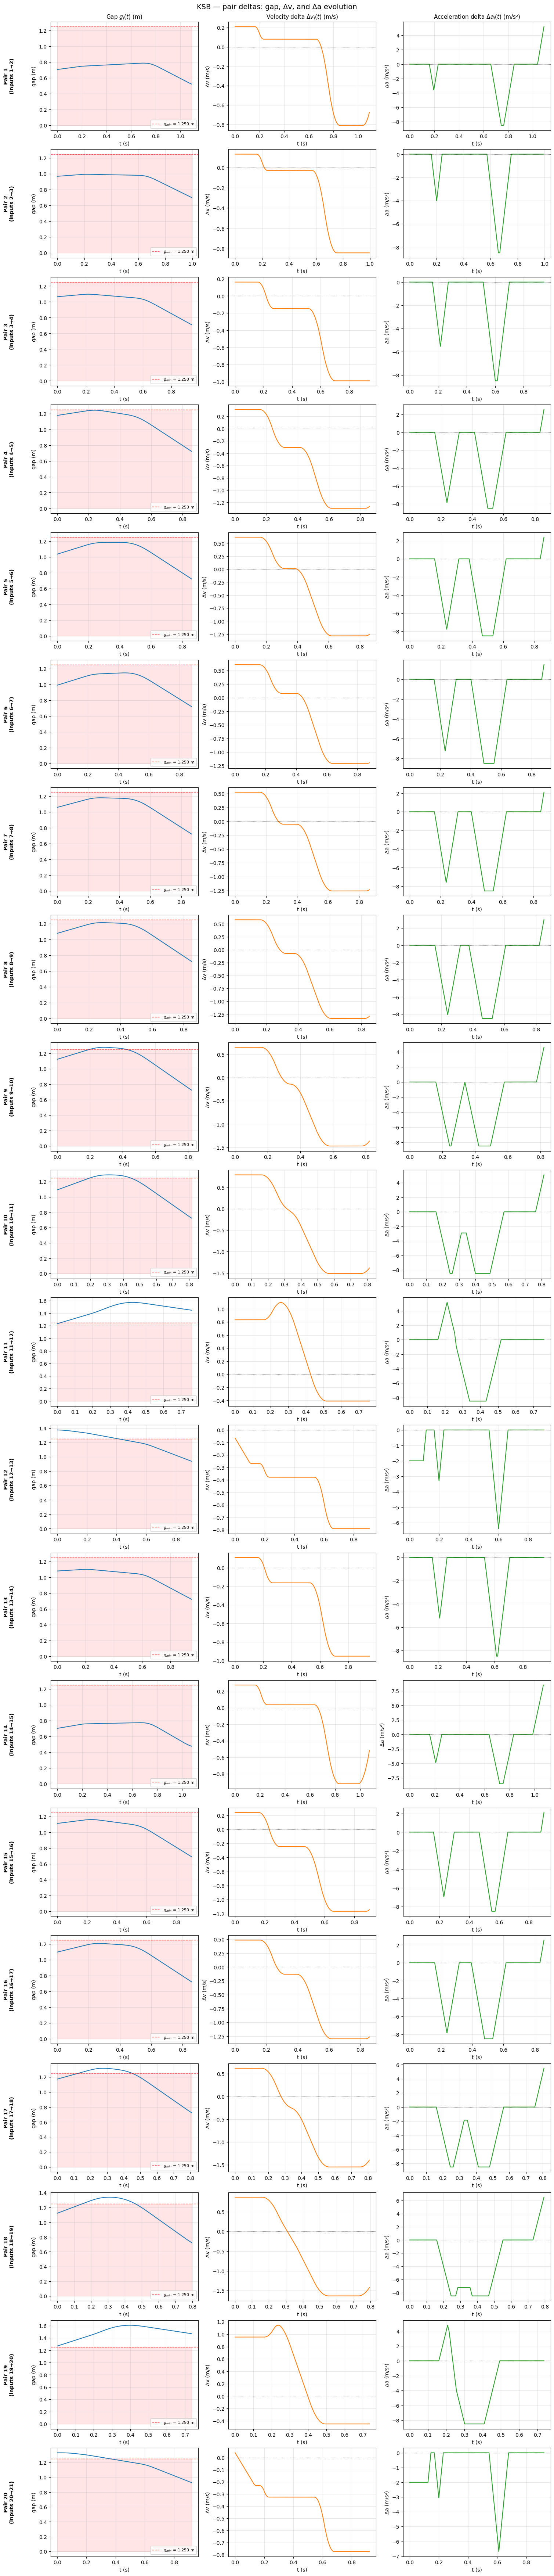

In [4]:
# Plot first 20 pairs
fig = plot_pair_deltas(result, N=20, i_start=0)